# 1. Project Introduction

Coronaviruses are a family of viruses that can cause illness ranging from the common cold and cough to more severe diseases. Middle East Respiratory Syndrome (MERS-CoV) and Severe Acute Respiratory Syndrome (SARS-CoV) are examples of serious outbreaks the world has previously faced.

SARS-CoV-2 (the novel coronavirus) is a new virus belonging to the coronavirus family. It was first identified in 2019 and had not previously been detected in humans.

It is a contagious virus that originated in Wuhan in December 2019. Due to its rapid global spread, it was later declared a pandemic by the World Health Organization (WHO). As of April 21, 2021, this has resulted in more than 500,000 deaths worldwide.

As the pandemic continues to spread across the globe, understanding its transmission and impact has become increasingly important. This notebook aims to analyze the accumulated data of confirmed cases, deaths, and recoveries over time.


# Table of Contents

* [2. Downloading and Installing Prerequisites](#2.-Downloading-and-Installing-Prerequisites)

* [3. Downloading the Dataset and Exploring the Data](#3.-Downloading-the-Dataset)

* [4. Global Analysis](#4.-Global-Analysis)

    * [Problem 1](#Problem-1)
    * [Problem 2](#Problem-2)
    * [Problem 3](#Problem-3)
    * [Problem 4](#Problem-4)
    * [Problem 5](#Problem-5)
    * [Problem 6](#Problem-6)
    * [Problem 7](#Problem-7)

* [5. Continent Analysis](#5.-Continent-Analysis)

    * [Problem 8](#Problem-8)
    * [Problem 9](#Problem-9)
    * [Problem 10](#Problem-10)
    * [Problem 11](#Problem-11)
    * [Problem 12](#Problem-12)
    * [Problem 13](#Problem-13)

# 2. Downloading and Installing Prerequisites

**pycountry_convert**: Using country data sourced from Wikipedia, this package provides functions to convert between ISO country names, country codes, and continent names.

**folium, seaborn, plotly**: Visualization packages in Python used to create charts, maps, and interactive visualizations.

# 3. Downloading the Dataset and Exploring the Data

After downloading the dataset, answer the following questions:

- Identify the first date when the dataset started recording COVID-19 cases in all three datasets.
- Identify the most recent date when COVID-19 case data was updated in the three datasets.
- Determine how many countries are included in the dataset.
- Calculate the total number of days covered in the three datasets.
- Check whether there are any duplicated countries across the three datasets.
- Identify the countries in the three datasets where COVID-19 cases are recorded at the **national level** rather than by city.
- Identify the countries in the three datasets where COVID-19 cases are recorded **by city or province**.
- Determine the **country and date** with the highest number of COVID-19 cases.
- Identify the **country with the highest total number of COVID-19 deaths**.
- Calculate the **total number of cases, deaths, recoveries, and active cases in Vietnam at the most recent date**.

This dataset is updated daily by the **Johns Hopkins CSSE**.

In [1]:
!pip install pycountry_convert
!pip install folium
!pip install seaborn
!pip install plotly

In [2]:
#Importing the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import pycountry_convert as pc
import folium
from pycountry_convert import country_mappings as cm
from datetime import datetime, timedelta,date
from scipy.interpolate import make_interp_spline, BSpline
import plotly.express as px
import plotly.graph_objs as go
import json
import plotly.offline as py
import seaborn as sns
plt.style.use('fivethirtyeight')

In [3]:
# Global Data
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')
deaths_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')
recoveries_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv')

In [4]:
confirmed_df = confirmed_df.loc[:,:"8/4/21"]
deaths_df = deaths_df.loc[:,:"8/4/21"]
recoveries_df = recoveries_df.loc[:,:"8/4/21"]

## Overview of the Dataset

In [5]:
confirmed_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,144285,145008,145552,145996,146523,147154,147501,147985,148572,148933
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132891,132922,132952,132999,133036,133081,133121,133146,133211,133310
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,163660,165204,167131,168668,170189,171392,172564,173922,175229,176724
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,14577,14586,14586,14655,14678,14678,14678,14747,14766,14797
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,41879,42110,42288,42486,42646,42777,42815,42970,43070,43158


In [6]:
deaths_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,6477,6515,6577,6615,6677,6708,6737,6774,6804,6836
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2456,2456,2457,2457,2457,2457,2457,2457,2457,2457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,4087,4112,4161,4189,4219,4254,4291,4329,4370,4404
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,128,128,128,128,128,128
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,991,994,1000,1003,1008,1011,1016,1018,1022,1026


In [7]:
recoveries_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,82586,82586,82586,82586,82586,82586,82586,82586,82586,82586
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,130152,130166,130174,130187,130205,130222,130243,130256,130291,130314
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,111322,112050,112900,113707,114531,115276,116009,116770,117557,118409
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,14077,14113,14113,14180,14210,14210,14210,14296,14348,14380
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,35686,35742,35964,36025,36708,37255,37397,38360,39389,39582


# 4. Global Analysis

## Problem 1

Calculate the **total number of confirmed cases, deaths, recoveries, and active cases over time (by day)**.

In [8]:
cols = confirmed_df.keys()
confirmed = confirmed_df.loc[:, cols[4]:cols[-1]]
deaths = deaths_df.loc[:, cols[4]:cols[-1]]
recoveries = recoveries_df.loc[:, cols[4]:cols[-1]]
dates = confirmed.keys()

total_cases = confirmed.sum(axis = 0)
total_deaths = deaths.sum(axis = 0)
mortality_rate = total_deaths/total_cases
recovery_rate = total_cases/total_deaths
total_recovered = recoveries.sum(axis = 0)
total_active = total_cases - total_deaths - total_recovered
adjusted_dates = list(np.array([i for i in range(len(dates))]).reshape(-1, 1)[:, 0])

In [14]:
#  The number of total cases, total deaths, total recovered, and total active until now.
print("Total confirmed cases: ", total_cases[-1])
print("Total death cases: ", total_deaths[-1])
print("Total recoveries cases: ", total_recovered[-1])
print("Total active cases: ", total_active[-1])

Total confirmed cases:  200758588
Total death cases:  4283016
Total recoveries cases:  130899061
Total active cases:  65576511


/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/3018031447.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/3018031447.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/3018031447.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipyker

## Problem 2

Visualize the **total number of confirmed cases, deaths, recoveries, and active cases over time (daily)** using **two line charts**:

1. One chart with **raw numbers**  
2. Another chart with **logarithm base 10 (log10) of the numbers**

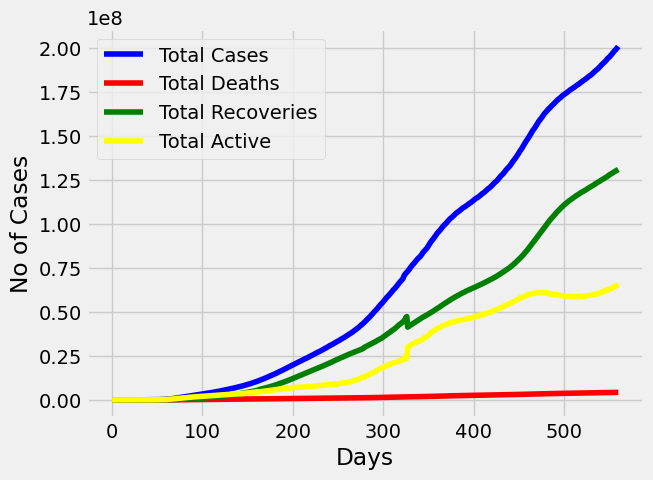

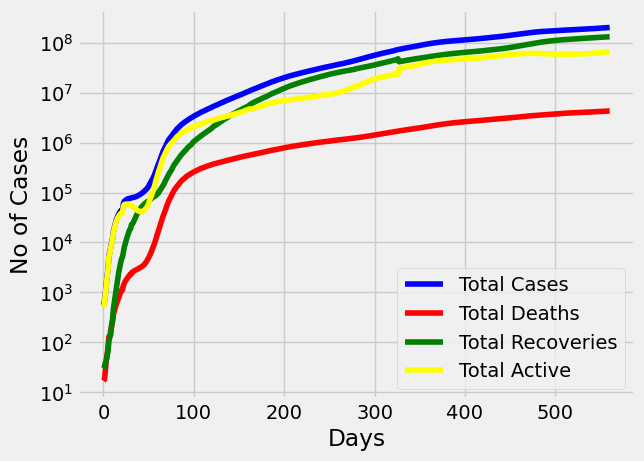

In [15]:
days_since = np.array([i for i in range(len(dates))]).reshape(-1, 1)
plt.plot(days_since,total_cases, label='Total Cases',color = "blue")
plt.plot(days_since,total_deaths, label='Total Deaths',color = "red")
plt.plot(days_since,total_recovered, label='Total Recoveries',color = "green")
plt.plot(days_since,total_active, label='Total Active',color = "yellow")
plt.legend(["Total Cases","Total Deaths","Total Recoveries","Total Active"])
plt.xlabel("Days")
plt.ylabel("No of Cases")
plt.show()

plt.plot(days_since,total_cases, label='Total Cases',color = "blue")
plt.plot(days_since,total_deaths, label='Total Deaths',color = "red")
plt.plot(days_since,total_recovered, label='Total Recoveries',color = "green")
plt.plot(days_since,total_active, label='Total Active',color = "yellow")
plt.yscale('log', base=10)
plt.legend(["Total Cases","Total Deaths","Total Recoveries","Total Active"])
plt.xlabel("Days")
plt.ylabel("No of Cases")
plt.show()

## Problem 3

Visualize the **total confirmed cases, deaths, recoveries, and active cases over time (daily)** using **four separate line charts**, one for each metric.

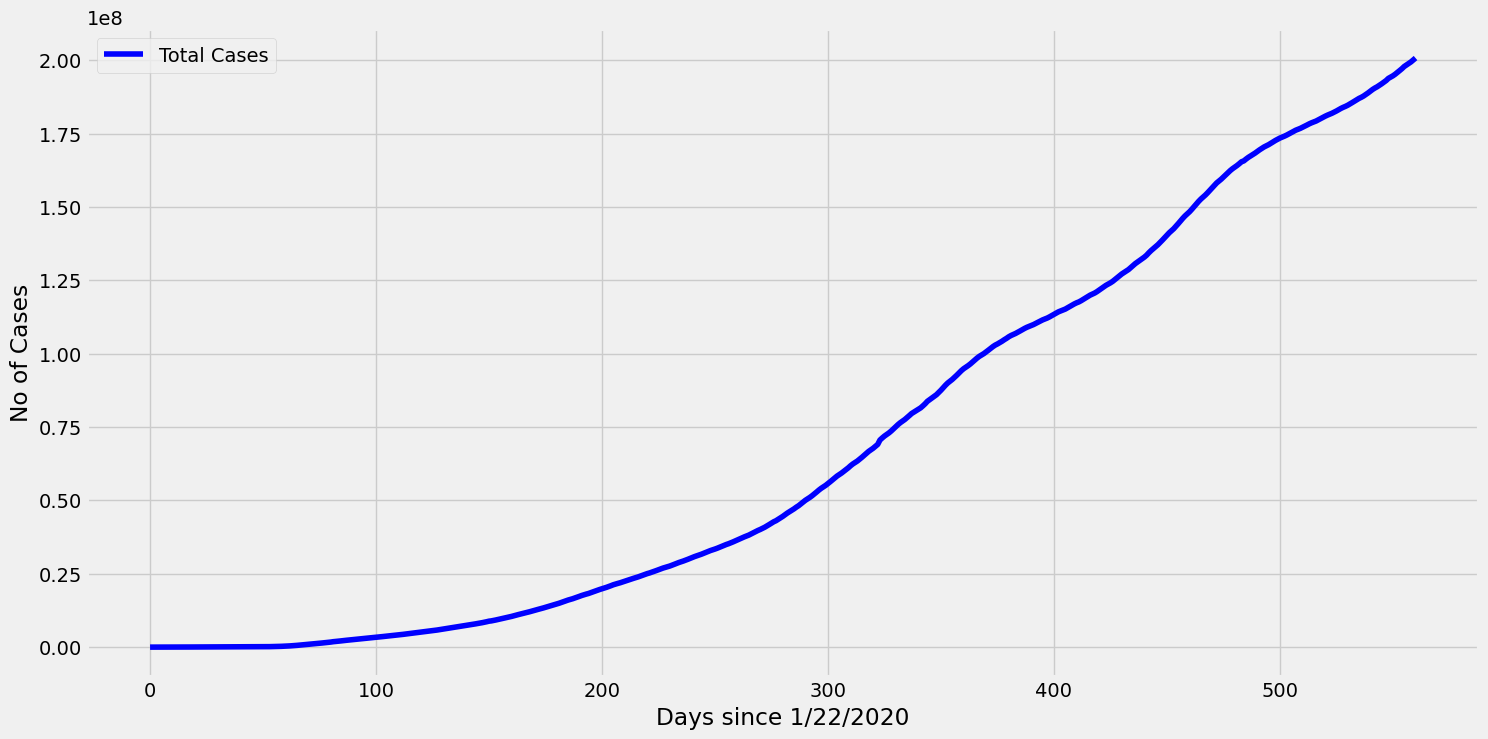

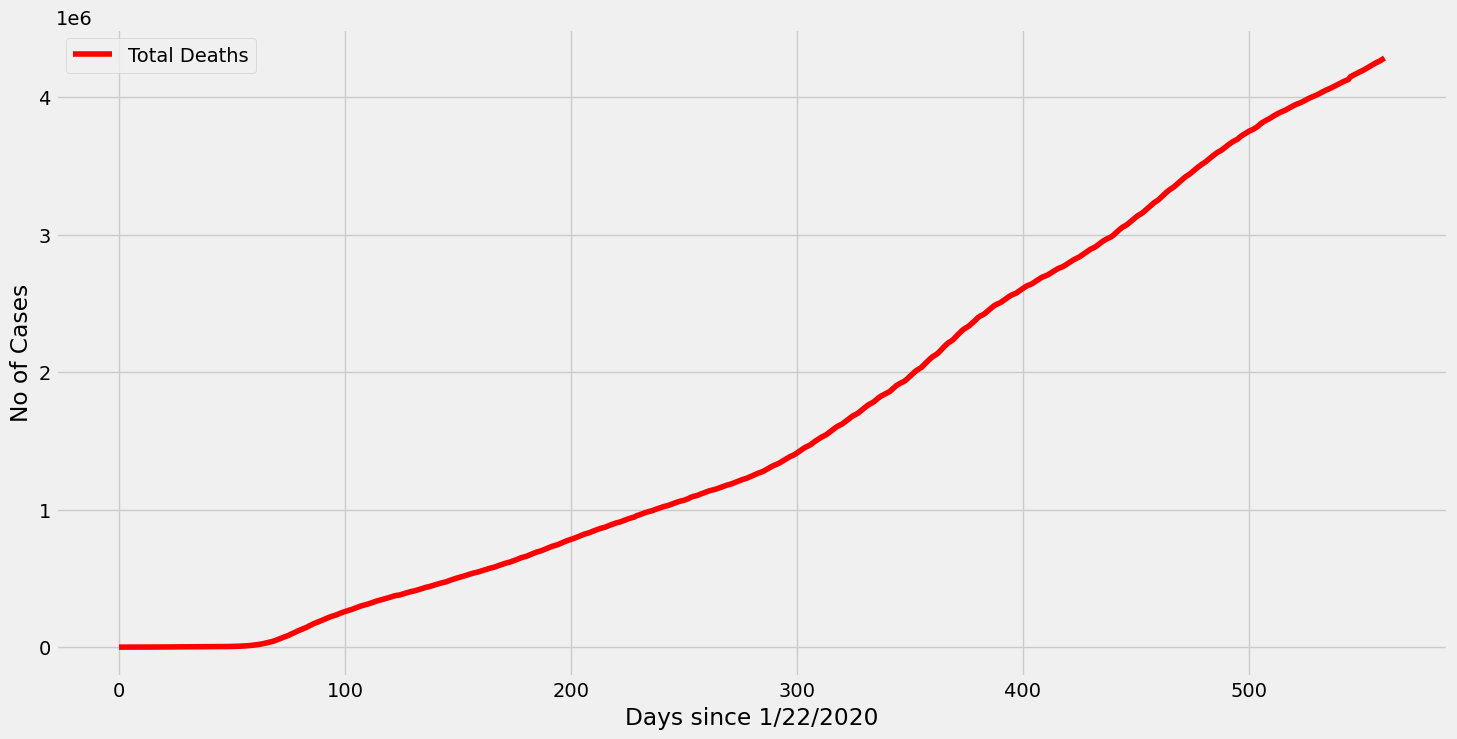

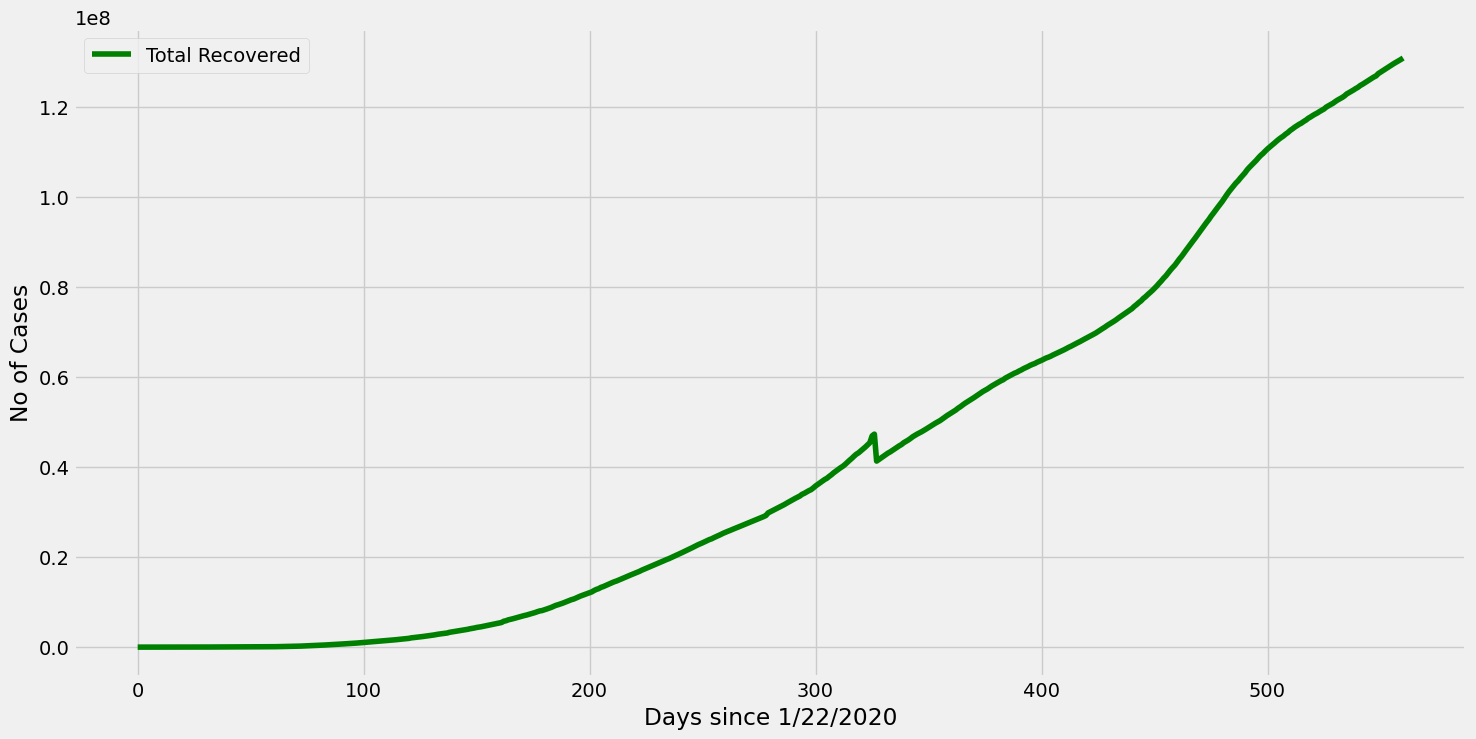

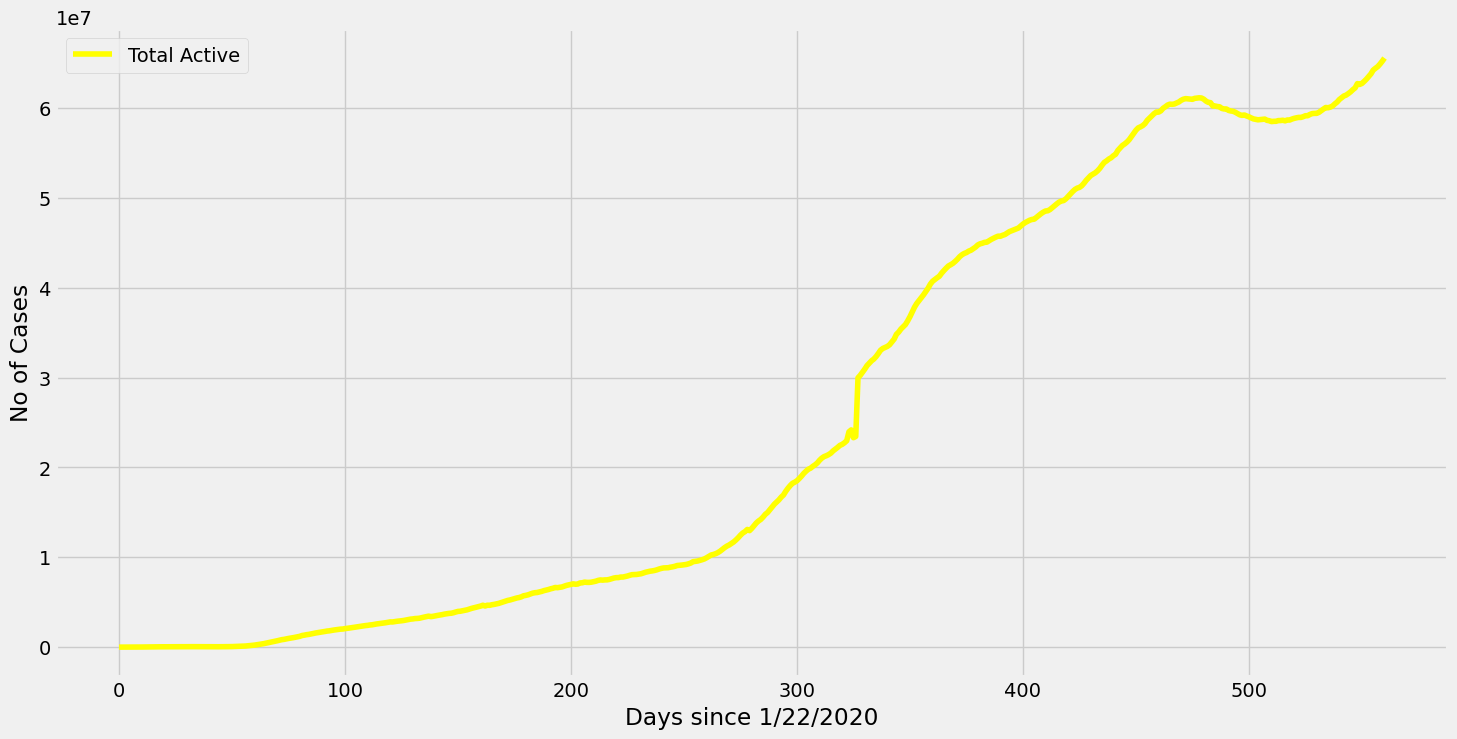

In [16]:
# Visualize the total number of cases, total number of deaths, total number of recoveries, and total number of active patients over time

# the total number of cases
plt.figure(figsize= (16,8))
plt.plot(days_since,total_cases, label='Total Cases',color = "blue")
plt.xlabel("Days since 1/22/2020")
plt.ylabel("No of Cases")
plt.legend(["Total Cases"])
plt.show()

# total number of deaths
plt.figure(figsize= (16,8))
plt.plot(days_since,total_deaths, label='Total Deaths',color = "red")
plt.xlabel("Days since 1/22/2020")
plt.ylabel("No of Cases")
plt.legend(["Total Deaths"])
plt.show()


# total number of recoveries
plt.figure(figsize= (16,8))
plt.plot(days_since,total_recovered, label='Total Recovered',color = "green")
plt.xlabel("Days since 1/22/2020")
plt.ylabel("No of Cases")
plt.legend(["Total Recovered"])
plt.show()


# total number of active patients
plt.figure(figsize= (16,8))
plt.plot(days_since,total_active, label='Total Active',color = "yellow")
plt.xlabel("Days since 1/22/2020")
plt.ylabel("No of Cases")
plt.legend(["Total Active"])
plt.show()

## Problem 4

Calculate the **daily increments** in **total confirmed cases, deaths, recoveries, and active cases** over time (by day).

In [17]:
# Calculate the daily increase in the total number of cases, total deaths, total recoveries,
# and total active cases over time (in days).

new_cases = total_cases.diff()
new_deaths = total_deaths.diff()
new_recoveries = total_recovered.diff()
new_active = new_cases - new_deaths - new_recoveries

print("New cases: ", new_cases[-1])
print("New deaths: ", new_deaths[-1])
print("New recoveries: ", new_recoveries[-1])
print("New active: ", new_active[-1])

New cases:  680458.0
New deaths:  10492.0
New recoveries:  317060.0
New active:  352906.0


/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/2510979944.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/2510979944.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/2510979944.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipyke

## Problem 5

Visualize the **daily increments** of **total confirmed cases, deaths, recoveries, and active cases** over time using **4 separate bar charts**.

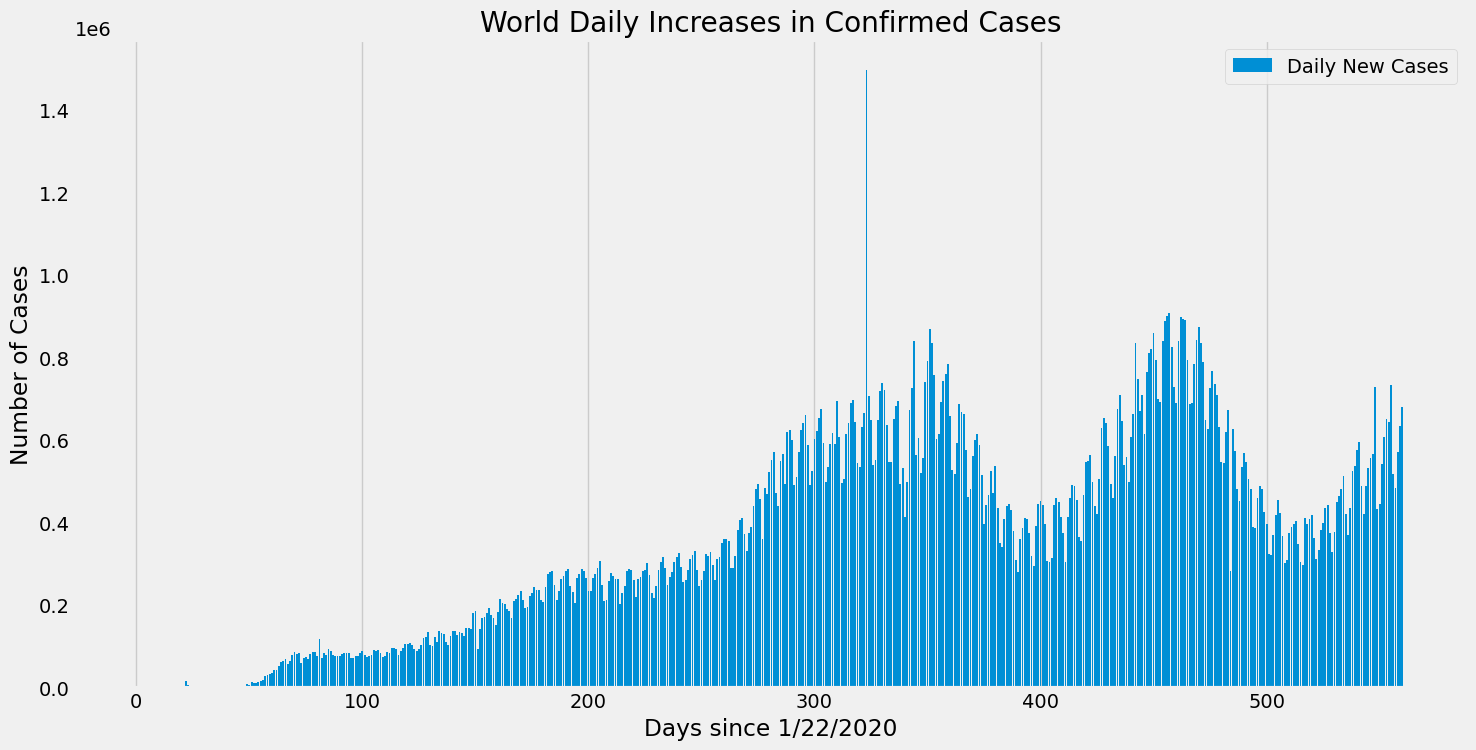

In [45]:
# the daily increase in the total number of cases
plt.figure(figsize=(16, 8))

plt.bar(days_since.flatten(), new_cases, label='Daily New Cases')

plt.title('World Daily Increases in Confirmed Cases')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.legend()
plt.grid(axis='y')
plt.show()


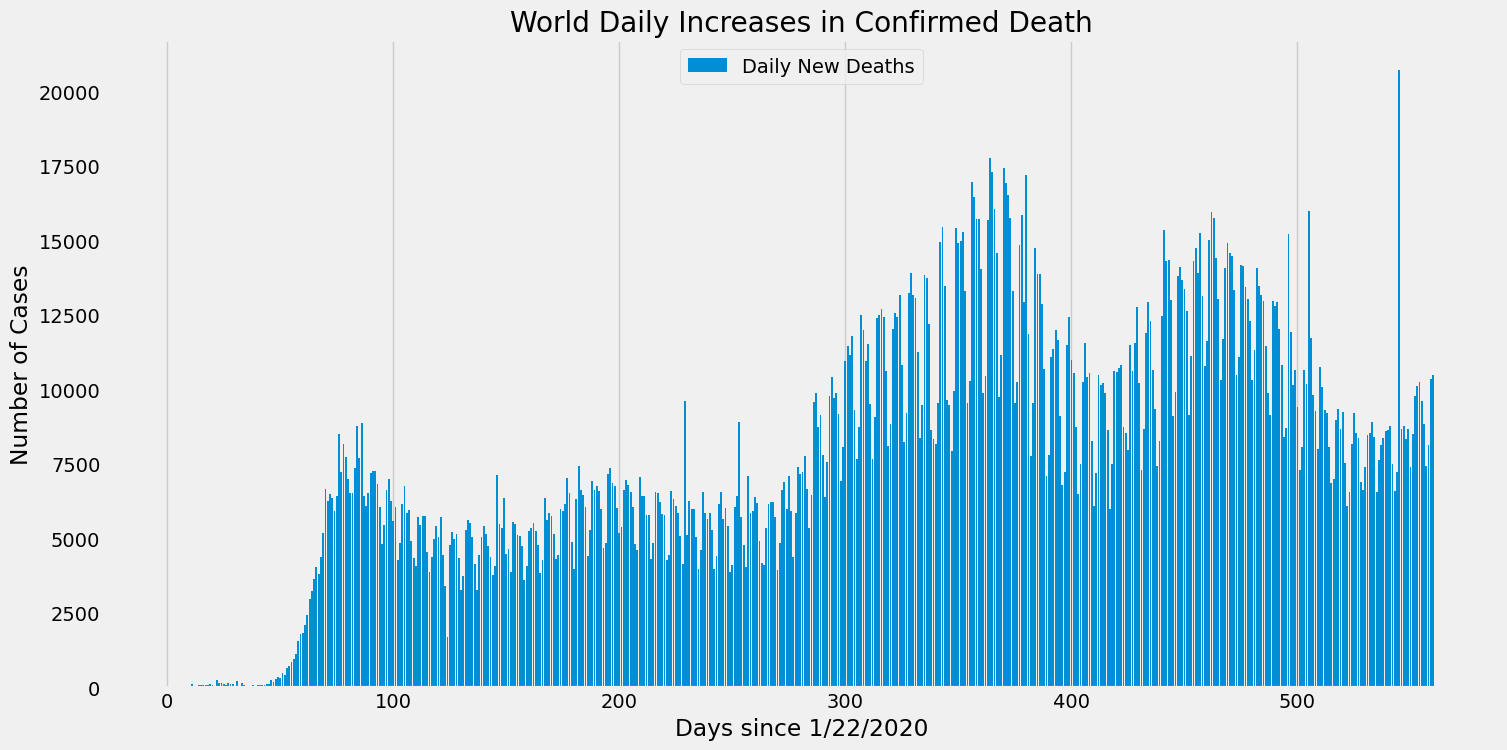

In [18]:
# the daily increase in the total number of deaths
plt.figure(figsize=(16, 8))

plt.bar(days_since.flatten(), new_deaths, label='Daily New Deaths')

plt.title('World Daily Increases in Confirmed Death')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.legend()
plt.grid(axis='y')
plt.show()

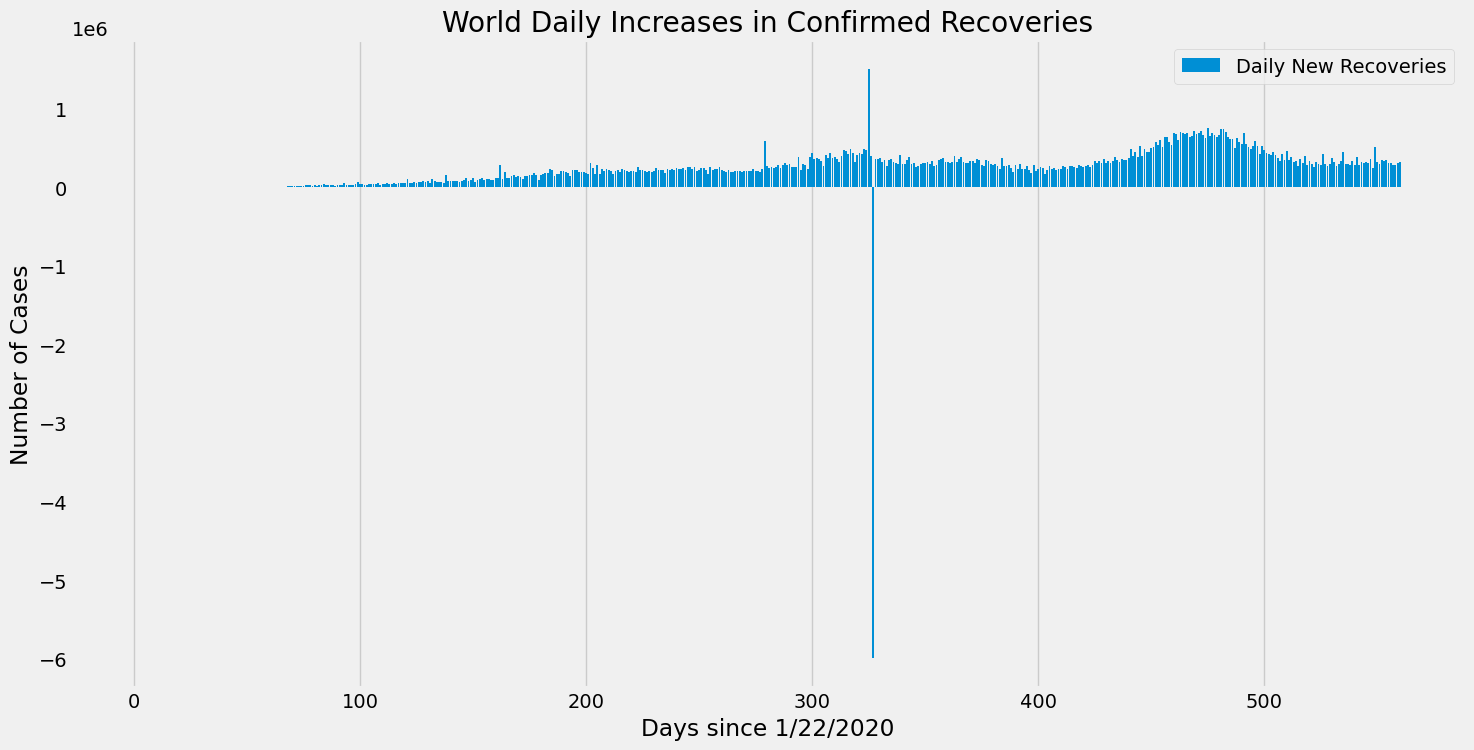

In [19]:
# the daily increase in the total number of recoveries
plt.figure(figsize=(16,8))

plt.bar(days_since.flatten(), new_recoveries,label='Daily New Recoveries')

plt.title('World Daily Increases in Confirmed Recoveries')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.legend()
plt.grid(axis='y')
plt.show()

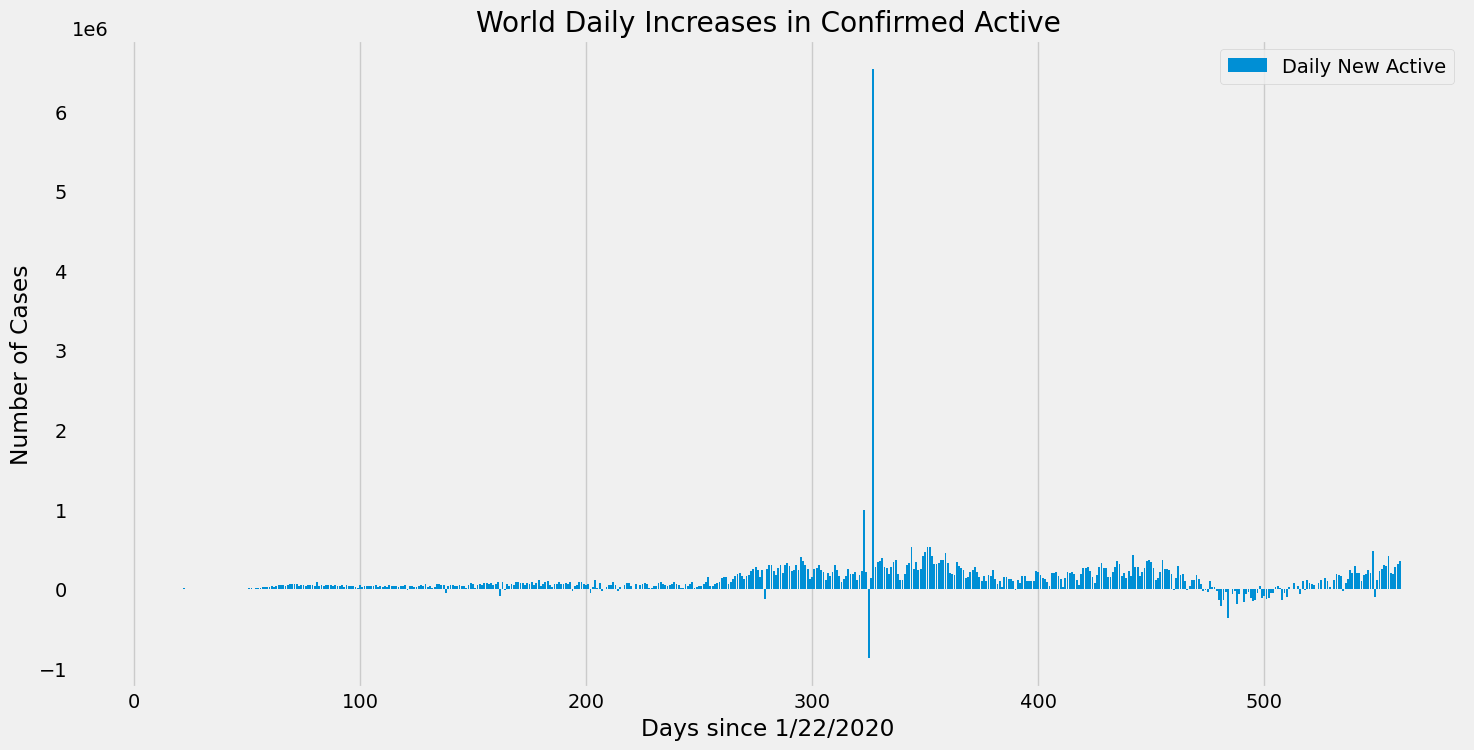

In [20]:
# the daily increase in the total number of active
plt.figure(figsize=(16, 8))

plt.bar(days_since.flatten(), new_active, label='Daily New Active')

plt.title('World Daily Increases in Confirmed Active')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.legend()
plt.grid(axis='y')
plt.show()

## Problem 6

Calculate the **global case fatality rate (CFR)** and **recovery rate** as percentages over time.

In [21]:
# Calculate the global mortality rate and recovery rate as a percentage over time.

mortality_rate = np.divide(
    total_deaths,
    total_cases,
    out=np.zeros_like(total_deaths, dtype=float),
    where=total_cases != 0
) * 100

recovery_rate = np.divide(
    total_recovered,
    total_cases,
    out=np.zeros_like(total_recovered, dtype=float),
    where=total_cases != 0
) * 100

print("Mortality Rate: ", mortality_rate[-1])
print("Recovery Rate: ", recovery_rate[-1])

Mortality Rate:  2.1334160808104508
Recovery Rate:  65.202222382636


/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/4169300209.py:17: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/wc/_h34vbd1295992s5775g0j3w0000gn/T/ipykernel_5601/4169300209.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



## Problem 7

### 7.1

Visualize the **daily case fatality rate (CFR) over time** using a **line chart**, and overlay a **dashed line showing the overall average CFR**.

Average Mortality:  3.438476174895814


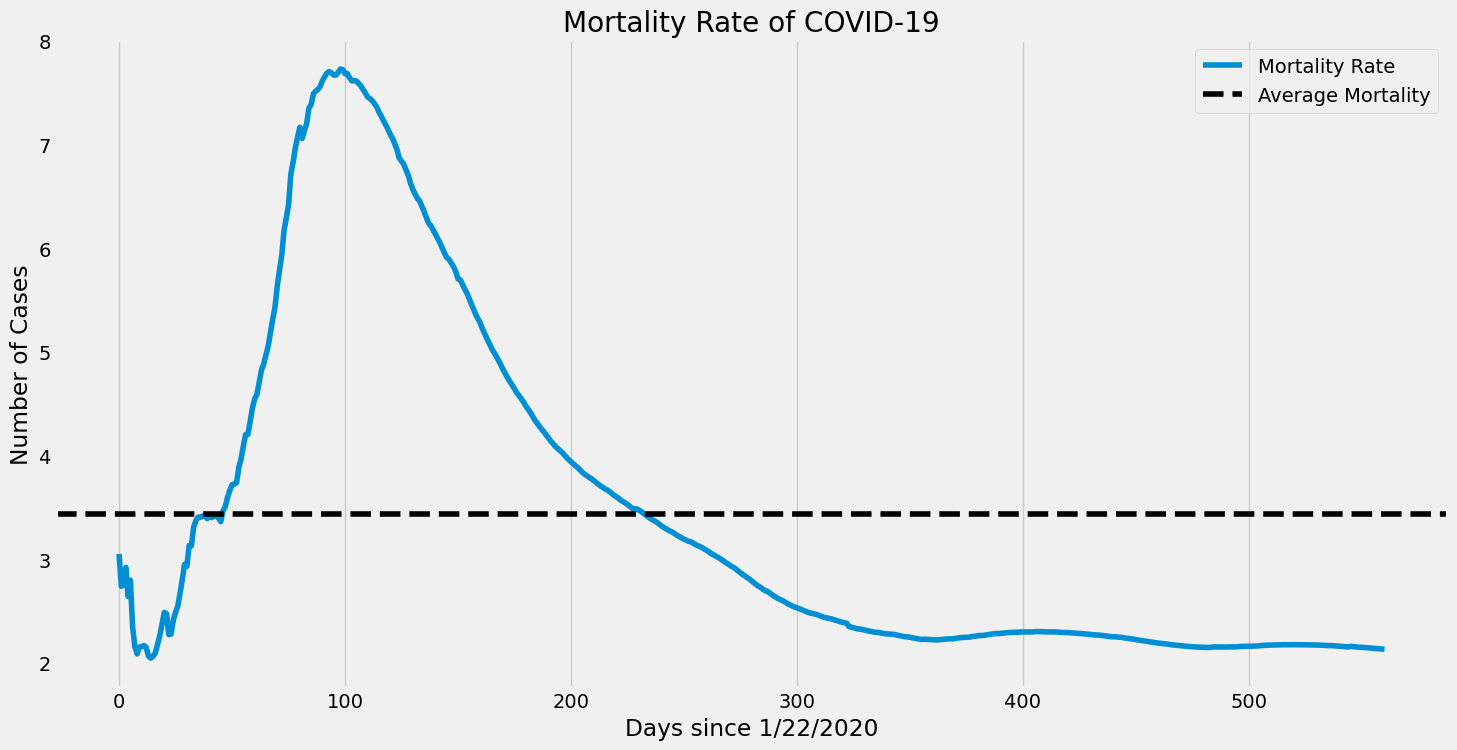

In [50]:
#Visualize mortality rates over time (in days) using a line graph.
#Use a dashed line to visualize the average mortality rate over time.

plt.figure(figsize=(16, 8))

plt.plot(days_since, mortality_rate, label='Mortality Rate')

plt.title('Mortality Rate of COVID-19')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.grid(axis='y')
plt.axhline(y=mortality_rate.mean(axis= 0), color='black', linestyle='--', label='Average Mortality')
print("Average Mortality: ", mortality_rate.mean(axis= 0))

plt.legend()
plt.show()

### 7.2

Visualize the **daily recovery rate over time** using a **line chart**, and overlay a **dashed line showing the overall average recovery rate**.

Average Recovery:  52.71640799696072


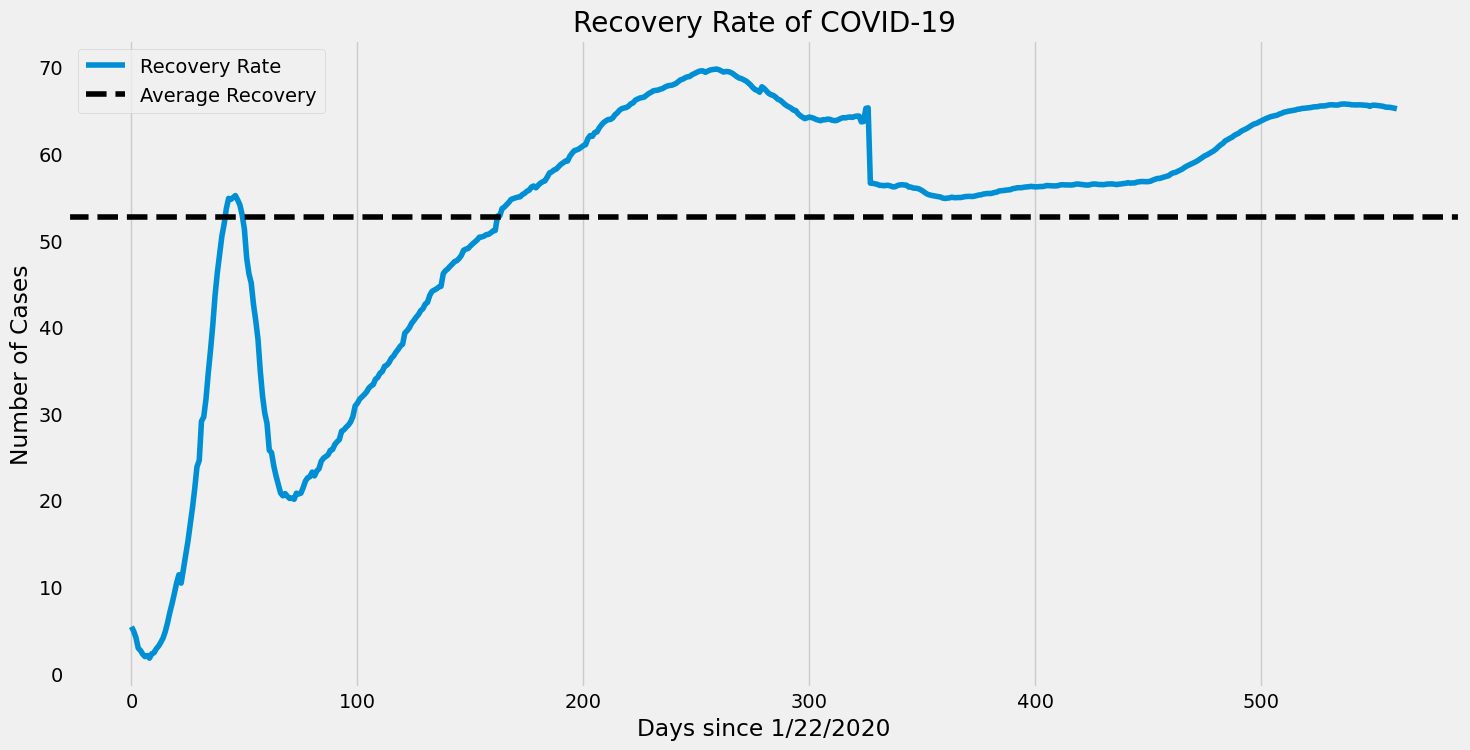

In [51]:
# Visualize the recovery rate over time (in days) using a line graph.
#Use a dashed line to visualize the average mortality rate over time.

plt.figure(figsize=(16, 8))

plt.plot(adjusted_dates, recovery_rate, label='Recovery Rate')

plt.title('Recovery Rate of COVID-19')
plt.xlabel('Days since 1/22/2020')
plt.ylabel('Number of Cases')

plt.grid(axis='y')
plt.axhline(y=recovery_rate.mean(axis= 0), color='black', linestyle='--', label='Average Recovery')
print("Average Recovery: ", recovery_rate.mean(axis= 0))

plt.legend()
plt.show()

#  5. Analysis by continent

## Data Preprocessing

In [53]:
# Changing the conuntry names as required by pycountry_convert Lib
confirmed_df.loc[confirmed_df['Country/Region'] == "US", "Country/Region"] = "USA"
deaths_df.loc[deaths_df['Country/Region'] == "US", "Country/Region"] = "USA"
recoveries_df.loc[recoveries_df['Country/Region'] == "US", "Country/Region"] = "USA"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Korea, South', "Country/Region"] = 'South Korea'
deaths_df.loc[deaths_df['Country/Region'] == 'Korea, South', "Country/Region"] = 'South Korea'
recoveries_df.loc[recoveries_df['Country/Region'] == "Korea, South", "Country/Region"] = "South Korea"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Taiwan*', "Country/Region"] = 'Taiwan'
deaths_df.loc[deaths_df['Country/Region'] == 'Taiwan*', "Country/Region"] = 'Taiwan'
recoveries_df.loc[recoveries_df['Country/Region'] == "Taiwan*", "Country/Region"] = "Taiwan"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Congo (Kinshasa)', "Country/Region"] = 'Democratic Republic of the Congo'
deaths_df.loc[deaths_df['Country/Region'] == 'Congo (Kinshasa)', "Country/Region"] = 'Democratic Republic of the Congo'
recoveries_df.loc[recoveries_df['Country/Region'] == "Congo (Kinshasa)", "Country/Region"] = "Democratic Republic of the Congo"

confirmed_df.loc[confirmed_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"
deaths_df.loc[deaths_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"
recoveries_df.loc[recoveries_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"

confirmed_df.loc[confirmed_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"
deaths_df.loc[deaths_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"
recoveries_df.loc[recoveries_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Congo (Brazzaville)', "Country/Region"] = 'Republic of the Congo'
deaths_df.loc[deaths_df['Country/Region'] == 'Congo (Brazzaville)', "Country/Region"] = 'Republic of the Congo'
recoveries_df.loc[recoveries_df['Country/Region'] == "Congo (Brazzaville)", "Country/Region"] = "Republic of the Congo"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Bahamas, The', "Country/Region"] = 'Bahamas'
deaths_df.loc[deaths_df['Country/Region'] == 'Bahamas, The', "Country/Region"] = 'Bahamas'
recoveries_df.loc[recoveries_df['Country/Region'] == "Bahamas, The", "Country/Region"] = "Bahamas"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Gambia, The', "Country/Region"] = 'Gambia'
deaths_df.loc[deaths_df['Country/Region'] == 'Gambia, The', "Country/Region"] = 'Gambia'
recoveries_df.loc[recoveries_df['Country/Region'] == "Gambia, The", "Country/Region"] = "Gambia"

# getting all countries
countries = np.asarray(confirmed_df["Country/Region"])
countries1 = np.asarray(deaths_df["Country/Region"])
countries2 = np.asarray(recoveries_df["Country/Region"])

# Continent_code to Continent_names
continents = {
    'NA': 'North America',
    'SA': 'South America',
    'AS': 'Asia',
    'OC': 'Australia',
    'AF': 'Africa',
    'EU' : 'Europe',
    'na' : 'Others'
}

# Defininng Function for getting continent code for country.
def country_to_continent_code(country):
    try:
        return pc.country_alpha2_to_continent_code(pc.country_name_to_country_alpha2(country))
    except :
        return 'na'

## Problem 8

Add a **"Continent"** column to the datasets: `confirm_df`, `death_df`, and `recoveries_df`.

In [54]:
# Function to add/re-add the Continent column robustly
def add_continent_column(df):
    if 'Continent' in df.columns:
        df = df.drop(columns=['Continent'])
    # Insert 'Continent' column at index 2 (after 'Country/Region')
    df.insert(2, "Continent", df["Country/Region"].apply(country_to_continent_code).map(continents))
    return df

confirmed_df = add_continent_column(confirmed_df)
deaths_df = add_continent_column(deaths_df)
recoveries_df = add_continent_column(recoveries_df)

# Display the head of confirmed_df to show the updated 'Continent' column with full names
confirmed_df.head()

,Province/State,Country/Region,Continent,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,Asia,33.93911,67.709953,0,0,0,0,0,...,144285,145008,145552,145996,146523,147154,147501,147985,148572,148933
1,NaN,Albania,Europe,41.15330,20.168300,0,0,0,0,0,...,132891,132922,132952,132999,133036,133081,133121,133146,133211,133310
2,NaN,Algeria,Africa,28.03390,1.659600,0,0,0,0,0,...,163660,165204,167131,168668,170189,171392,172564,173922,175229,176724
3,NaN,Andorra,Europe,42.50630,1.521800,0,0,0,0,0,...,14577,14586,14586,14655,14678,14678,14678,14747,14766,14797
4,NaN,Angola,Africa,-11.20270,17.873900,0,0,0,0,0,...,41879,42110,42288,42486,42646,42777,42815,42970,43070,43158


## Problem 9

Create a **DataFrame `country_df`** indexed by `"Country/Region"` with the following columns:

- `Continent`: Continent of the country  
- `Confirmed`: Total confirmed cases  
- `Deaths`: Total deaths  
- `Recoveries`: Total recovered cases  
- `Active`: Total active cases  
- `Mortality Rate`: Case fatality rate (%)  

In [55]:
# Select the identifying columns explicitly in the desired order
base_info_cols = confirmed_df[['Province/State', 'Continent', 'Country/Region', 'Lat', 'Long']]

# Concatenate the base info columns with the latest confirmed, deaths, and recoveries data
full_table = pd.concat([
    base_info_cols,
    confirmed_df.iloc[:, -1].rename('Confirmed'), # Rename to 'Confirmed' directly
    deaths_df.iloc[:, -1].rename('Deaths'),       # Rename to 'Deaths' directly
    recoveries_df.iloc[:, -1].rename('Recoveries') # Rename to 'Recoveries' directly
], axis=1)

# Calculate active cases
full_table['Active'] = full_table['Confirmed'] - full_table['Deaths'] - full_table['Recoveries']

# Calculate mortality rate
full_table['Mortality Rate'] = round((full_table['Deaths'] / full_table['Confirmed']) * 100, 2)

# Group by country and aggregate
country_df = full_table.groupby('Country/Region').agg({
    'Continent': 'first', # Take the first continent as countries might have multiple rows (e.g., US states)
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recoveries': 'sum',
    'Active': 'sum',
    'Mortality Rate': lambda x: round(x.mean(), 2) # Average mortality rate for the country
}).reset_index()

# Set 'Country/Region' as index
country_df = country_df.set_index('Country/Region')

country_df.head()

,Continent,Confirmed,Deaths,Recoveries,Active,Mortality Rate
Country/Region,,,,,,
Afghanistan,Asia,148933,6836,82586.0,59511.0,4.59
Albania,Europe,133310,2457,130314.0,539.0,1.84
Algeria,Africa,176724,4404,118409.0,53911.0,2.49
Andorra,Europe,14797,128,14380.0,289.0,0.87
Angola,Africa,43158,1026,39582.0,2550.0,2.38


## Problem 10

Create a **DataFrame `continental_df`** indexed by `"Continent"` with the following columns:

- `Confirmed`: Total confirmed cases in the continent  
- `Deaths`: Total deaths in the continent  
- `Recoveries`: Total recovered cases in the continent  
- `Active`: Total active cases in the continent  
- `Mortality Rate`: Case fatality rate (%) for the continent  

In [56]:
# Group by Continent and aggregate
Continental_df = country_df.groupby('Continent').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recoveries': 'sum',
    'Active': 'sum'
}).reset_index()

# Recalculate Mortality Rate for continents
Continental_df['Mortality Rate'] = round((Continental_df['Deaths'] / Continental_df['Confirmed']) * 100, 2)

# Set 'Continent' as index
Continental_df = Continental_df.set_index('Continent')

Continental_df.head()

,Confirmed,Deaths,Recoveries,Active,Mortality Rate
Continent,,,,,
Africa,6855602,174000,51811682.0,-45434256.0,2.54
Asia,62536726,902952,17011297.0,44305332.0,1.44
Australia,90000,1425,5594246.0,-5505674.0,1.58
Europe,52448545,1167140,19516118.0,25966950.0,2.23
North America,42351963,924518,11308667.0,30118778.0,2.18


## Sample Line Charts

Below are **sample functions** to visualize COVID-19 cases over time for each **continent or country**.

In [57]:
def plot_params(ax,axis_label= None, plt_title = None,label_size=15, axis_fsize = 15, title_fsize = 20, scale = 'linear' ):
    # Tick-Parameters
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which='both', width=1,labelsize=label_size)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3, color='0.8')

    # Grid
    plt.grid(lw = 1, ls = '-', c = "0.7", which = 'major')
    plt.grid(lw = 1, ls = '-', c = "0.9", which = 'minor')

    # Plot Title
    plt.title( plt_title,{'fontsize':title_fsize})

    # Yaxis sacle
    plt.yscale(scale)
    plt.minorticks_on()
    # Plot Axes Labels
    xl = plt.xlabel(axis_label[0],fontsize = axis_fsize)
    yl = plt.ylabel(axis_label[1],fontsize = axis_fsize)

def visualize_covid_cases(confirmed, deaths,
                          continent=None , country = None , state = None, period = None, figure = None,
                          scale = "linear"):
    x = 0
    if figure == None:
        f = plt.figure(figsize=(10,10))
        # Sub plot
        ax = f.add_subplot(111)
    else :
        f = figure[0]
        # Sub plot
        ax = f.add_subplot(figure[1],figure[2],figure[3])
    ax.set_axisbelow(True)
    plt.tight_layout(pad=10, w_pad=5, h_pad=5)

    stats = [confirmed, deaths]
    label = ["Confirmed", "Deaths"]
    if continent != None:
       
        params = ["Continent",continent]
    elif country != None:
        params = ["country",country]
    else:
        params = ["All", "All"]
    color = ["blue","red","green"]
    marker_style = dict(linewidth=3, linestyle='-', marker='o',markersize=4, markerfacecolor='#ffffff')
    
    for i,stat in enumerate(stats):
        if params[1] == "All" :
            cases = np.sum(np.asarray(stat.iloc[:,5:]),axis = 0)[x:]
        else:
    
            cases = np.sum(np.asarray(stat[stat[params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        date = np.arange(1,cases.shape[0]+1)[x:]
        plt.plot(date,cases,label = label[i]+" (Total : "+str(cases[-1])+")",color=color[i],**marker_style)
        plt.fill_between(date,cases,color=color[i],alpha=0.3)
    if params[1] == "All" :
        Total_confirmed = np.sum(np.asarray(stats[0].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1].iloc[:,5:]),axis = 0)[x:]
    else :
    
        Total_confirmed =  np.sum(np.asarray(stats[0][stats[0][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1][stats[1][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]

    text = stats[0].columns[5]+" to "+stats[0].columns[-1]+"\n"
    text += "Mortality rate : "+ str(int(Total_deaths[-1]/(Total_confirmed[-1])*10000)/100)+"\n"
    text += "Last 5 Days:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-6])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-6])+"\n"
    text += "Last 24 Hours:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-2])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-2])+"\n"

    plt.text(0.02, 0.78, text, fontsize=15, horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.4))

    # Plot Axes Labels
    axis_label = ["Days ("+confirmed_df.columns[5]+" - "+confirmed_df.columns[-1]+")","No of Cases"]

    # Plot Parameters
    plot_params(ax,axis_label,scale = scale)

    # Plot Title
    if params[1] == "All" :
        plt.title("COVID-19 Cases World",{'fontsize':25})
    else:
        plt.title("COVID-19: "+params[1] ,{'fontsize':25})

    # Legend Location
    l = plt.legend(loc= "best",fontsize = 15)

    if figure == None:
        plt.show()

## Problem 11

### 11.1

Use the `visual_covid_case` function to **visualize COVID-19 cases for the 7 continents** in **7 separate line charts**.  
The charts should be **ordered by descending total confirmed cases**.

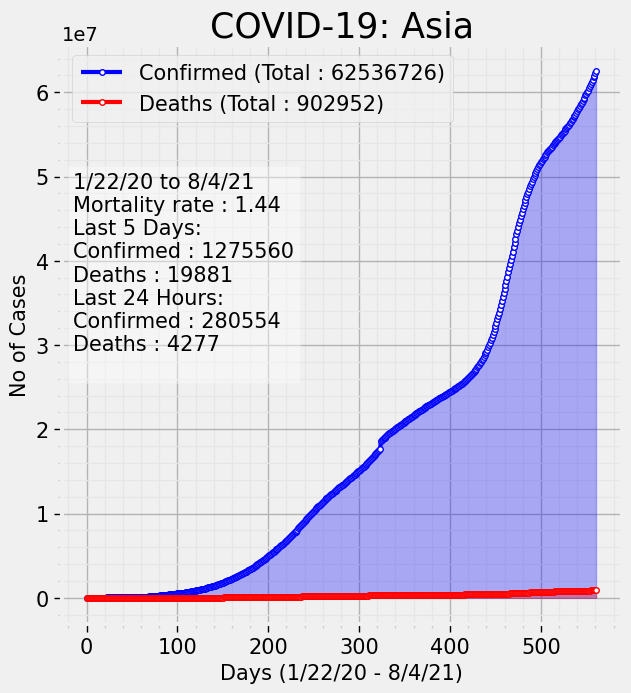

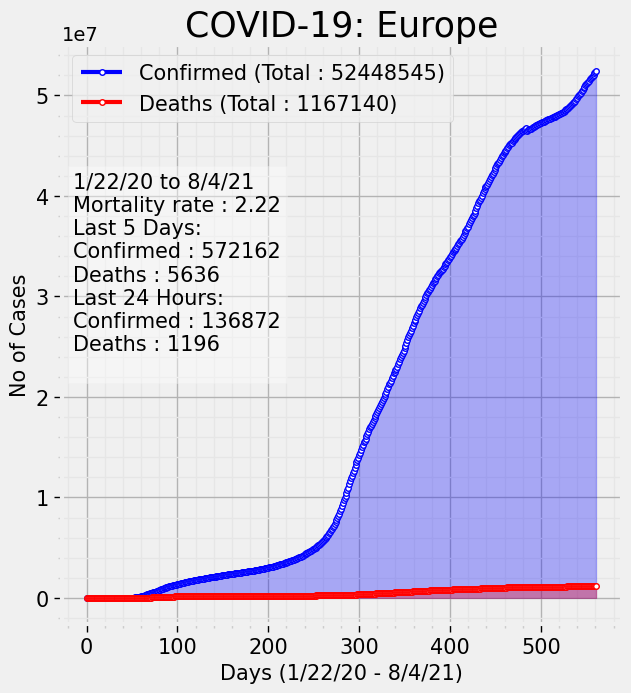

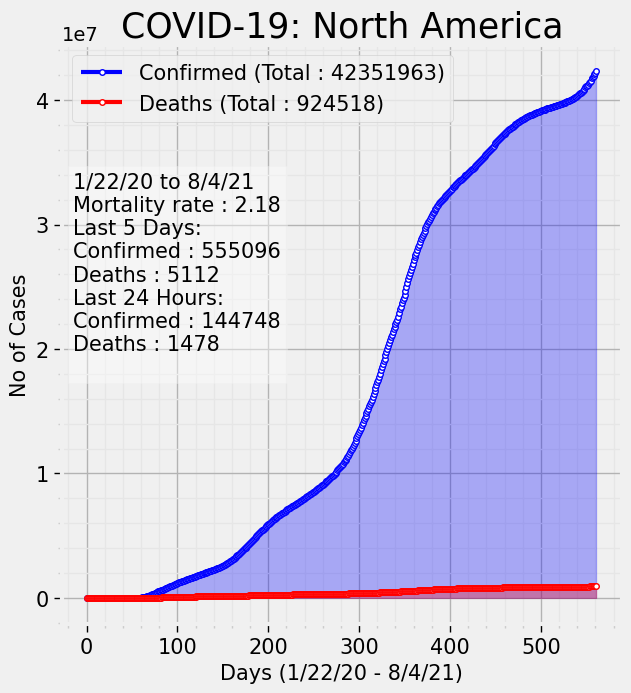

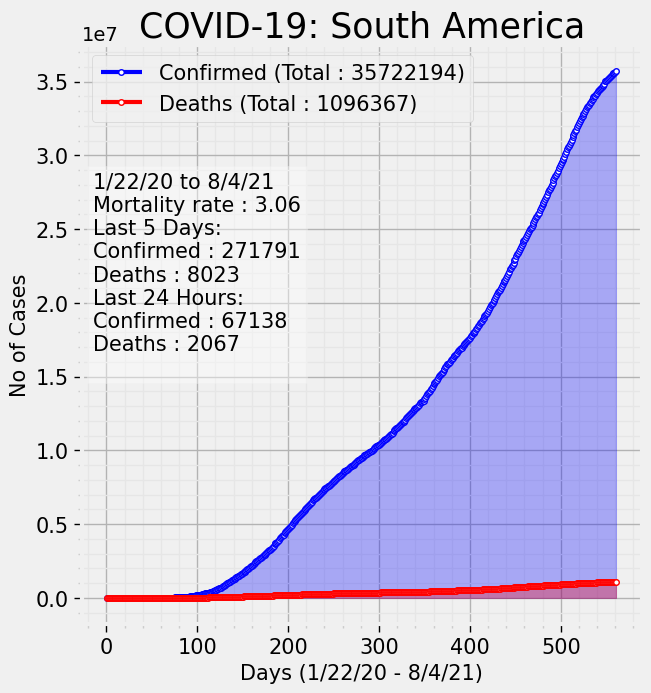

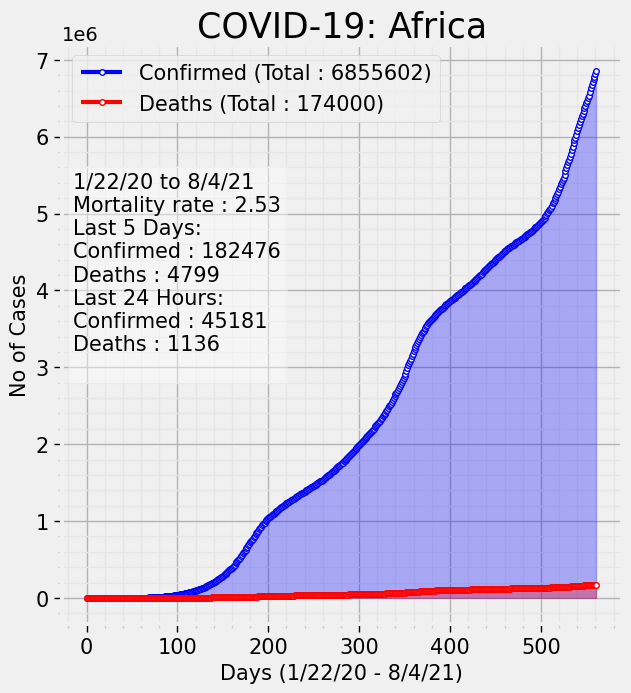

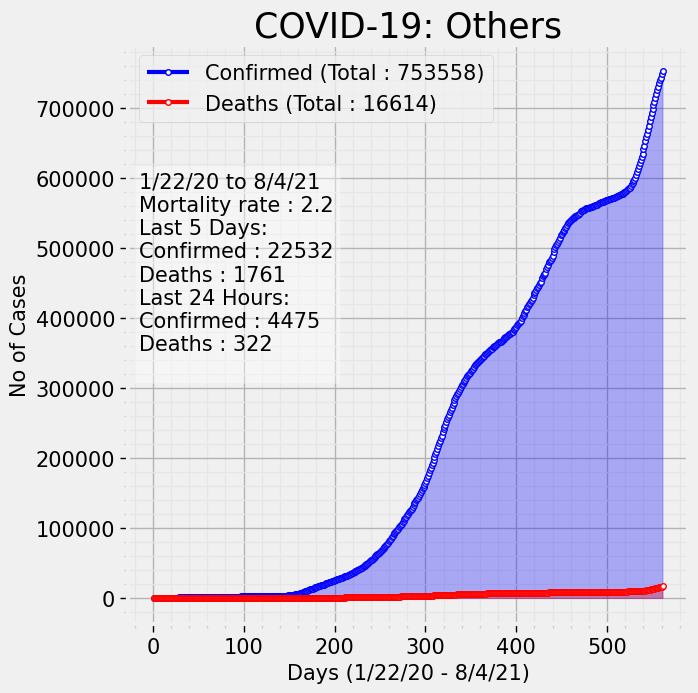

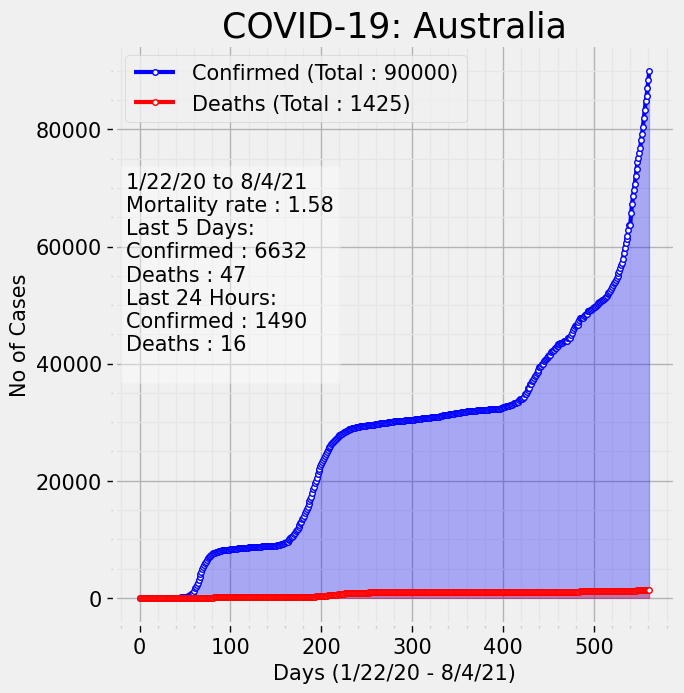

In [58]:
# Get unique continents and sort them by confirmed cases in descending order
continents_sorted_by_confirmed = Continental_df.sort_values(by='Confirmed', ascending=False).index.tolist()

# Visualize COVID cases for each continent
for continent in continents_sorted_by_confirmed:
    visualize_covid_cases(confirmed_df, deaths_df, continent=continent)
plt.show()

### 11.2

Modify **`plot_params`** and the **`visualize_covid_cases`** function to:

- Show data for the **last 7 days** instead of 5 days  
- Add a **"Recoveries" line** to the main chart  
- Include **"Total Recoveries"** in the small summary table  
- Display **Recoveries in the last 7 days and past 24 hours** in the info panel

In [59]:
def plot_params(ax,axis_label= None, plt_title = None,label_size=15, axis_fsize = 15, title_fsize = 20, scale = 'linear' ):
    # Tick-Parameters
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which='both', width=1,labelsize=label_size)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3, color='0.8')

    # Grid
    plt.grid(lw = 1, ls = '-', c = "0.7", which = 'major')
    plt.grid(lw = 1, ls = '-', c = "0.9", which = 'minor')

    # Plot Title
    plt.title( plt_title,{'fontsize':title_fsize})

    # Yaxis sacle
    plt.yscale(scale)
    plt.minorticks_on()
    # Plot Axes Labels
    xl = plt.xlabel(axis_label[0],fontsize = axis_fsize)
    yl = plt.ylabel(axis_label[1],fontsize = axis_fsize)

def visualize_covid_cases(confirmed, deaths, recoveries,
                          continent=None , country = None , state = None, period = None, figure = None,
                          scale = "linear"):
    x = 0
    if figure == None:
        f = plt.figure(figsize=(10,10))
        # Sub plot
        ax = f.add_subplot(111)
    else :
        f = figure[0]
        # Sub plot
        ax = f.add_subplot(figure[1],figure[2],figure[3])
    ax.set_axisbelow(True)
    plt.tight_layout(pad=10, w_pad=5, h_pad=5)

    stats = [confirmed, deaths, recoveries] # Added recoveries
    label = ["Confirmed", "Deaths", "Recovered"] # Added Recovered label
    if continent != None:
        params = ["Continent",continent]
    elif country != None:
        params = ["country",country]
    else:
        params = ["All", "All"]
    color = ["blue","red","green"] # Ensure enough colors
    marker_style = dict(linewidth=3, linestyle='-', marker='o',markersize=4, markerfacecolor='#ffffff')
    for i,stat in enumerate(stats):
        if params[1] == "All" :
            cases = np.sum(np.asarray(stat.iloc[:,5:]),axis = 0)[x:]
        else:
            cases = np.sum(np.asarray(stat[stat[params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        date = np.arange(1,cases.shape[0]+1)[x:]
        plt.plot(date,cases,label = label[i]+" (Total : "+str(cases[-1])+")",color=color[i],**marker_style)
        plt.fill_between(date,cases,color=color[i],alpha=0.3)
    if params[1] == "All" :
        Total_confirmed = np.sum(np.asarray(stats[0].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1].iloc[:,5:]),axis = 0)[x:]
        Total_recovered = np.sum(np.asarray(stats[2].iloc[:,5:]),axis = 0)[x:] # Added Total_recovered for 'All'
    else :
        Total_confirmed =  np.sum(np.asarray(stats[0][stats[0][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1][stats[1][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_recovered = np.sum(np.asarray(stats[2][stats[2][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:] # Added Total_recovered for specific continent/country

    text = stats[0].columns[5]+" to "+stats[0].columns[-1]+"\n"
    text += "Mortality rate : "+ str(int(Total_deaths[-1]/(Total_confirmed[-1])*10000)/100)+"\n"
    text += "Last 7 Days:\n" # Changed to Last 7 Days
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-8])+"\n" # Changed -6 to -8
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-8])+"\n" # Changed -6 to -8
    text += "Recovered : " + str(Total_recovered[-1] - Total_recovered[-8])+"\n" # Added Recovered for 7 days
    text += "Last 24 Hours:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-2])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-2])+"\n"
    text += "Recovered : " + str(Total_recovered[-1] - Total_recovered[-2])+"\n" # Added Recovered for 24 hours

    plt.text(0.02, 0.78, text, fontsize=15, horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.4))

    # Plot Axes Labels
    axis_label = ["Days ("+confirmed_df.columns[5]+" - "+confirmed_df.columns[-1]+")","No of Cases"]

    # Plot Parameters
    plot_params(ax,axis_label,scale = scale)

    # Plot Title
    if params[1] == "All" :
        plt.title("COVID-19 Cases World",{'fontsize':25})
    else:
        plt.title("COVID-19: "+params[1] ,{'fontsize':25})

    # Legend Location
    l = plt.legend(loc= "best",fontsize = 15)

    if figure == None:
        plt.show()

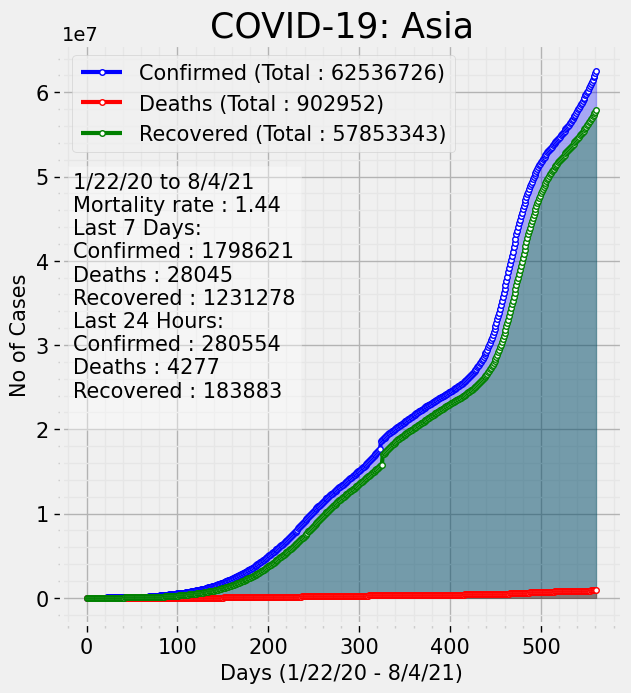

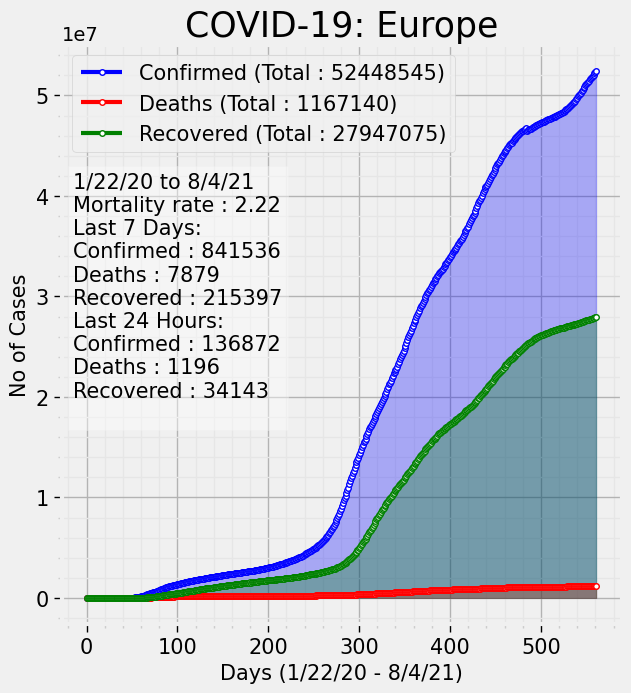

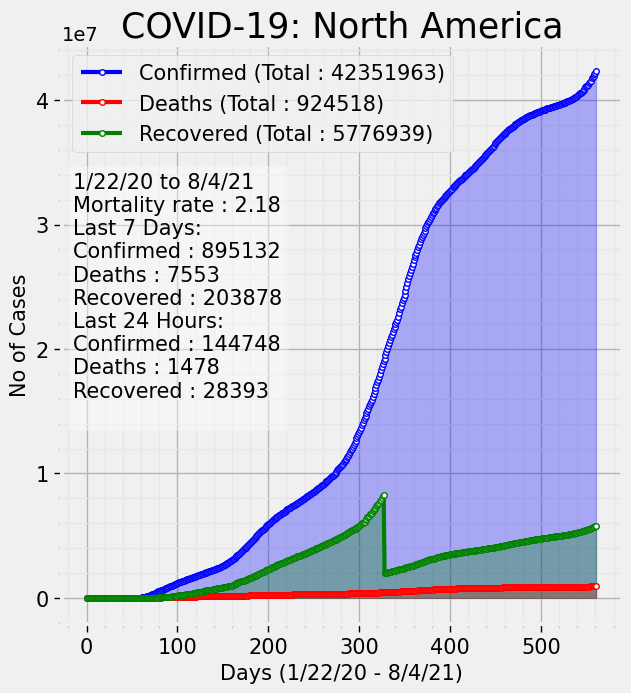

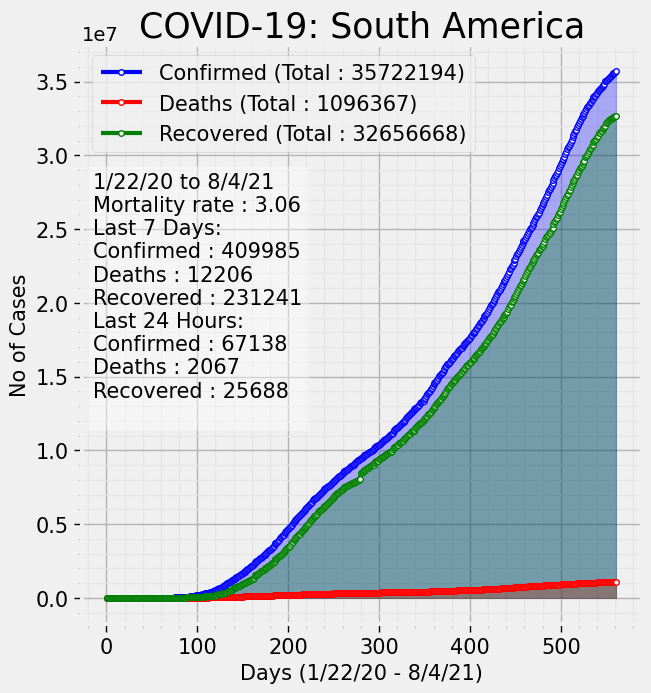

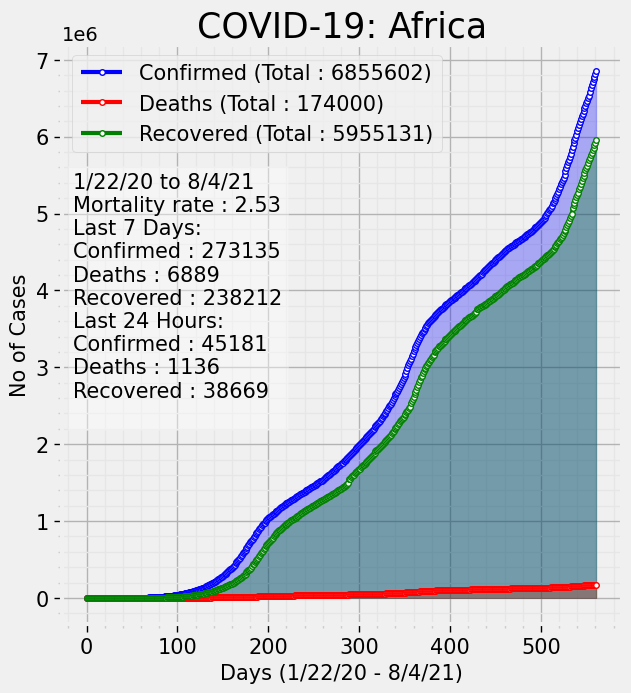

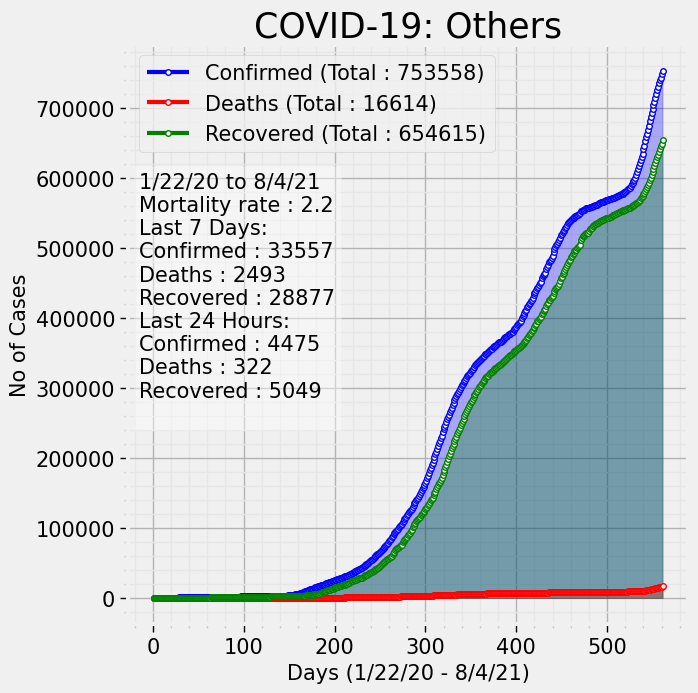

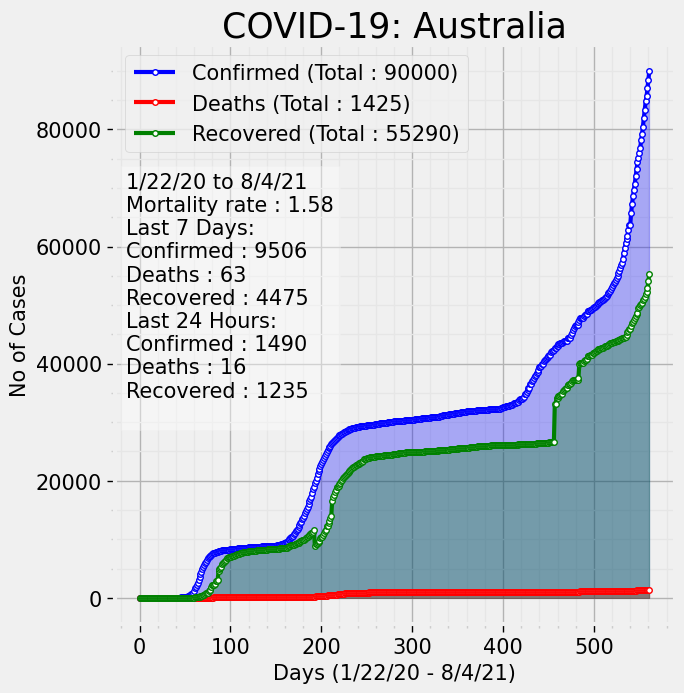

In [60]:
# Get unique continents and sort them by confirmed cases in descending order
continents_sorted_by_confirmed = Continental_df.sort_values(by='Confirmed', ascending=False).index.tolist()

# Visualize COVID cases for each continent
for continent in continents_sorted_by_confirmed:
    visualize_covid_cases(confirmed_df, deaths_df, recoveries_df, continent=continent)
plt.show()

## Problem 12

Visualize the **correlation matrix** of `continental_df` to understand relationships between metrics such as **Confirmed, Deaths, Recovered, Active, and Mortality Rate**.

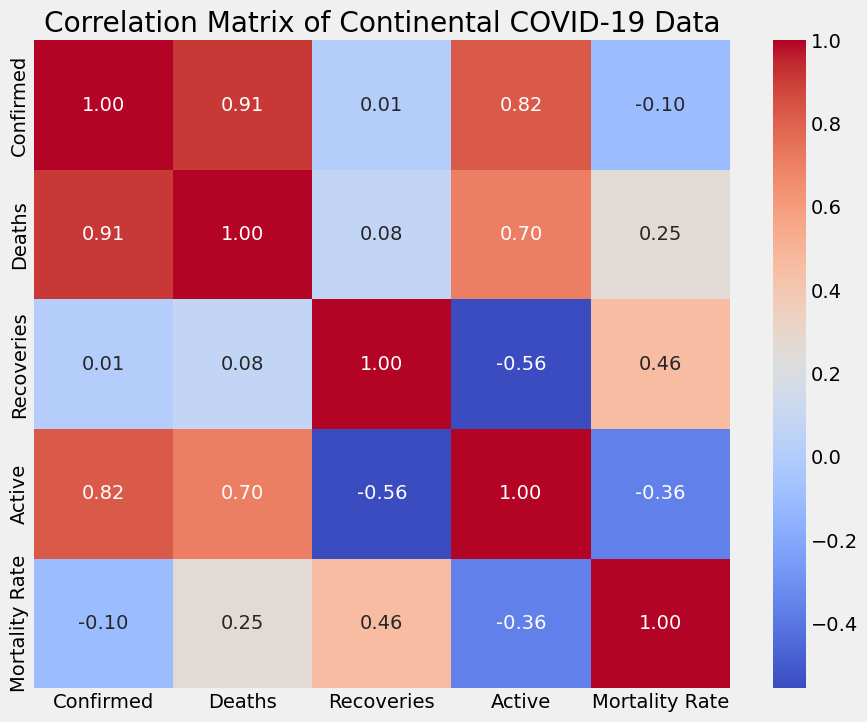

In [61]:
# Visualize the correlation matrix of continental_df

plt.figure(figsize=(10, 8))
sns.heatmap(Continental_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continental COVID-19 Data')
plt.show()

## Problem 13

Create **pie charts to compare the proportions of Confirmed, Deaths, Recovered, and Active cases across the 7 continents**.  
- Each metric should be shown in a **separate pie chart**.  
- Use a **for loop** to avoid repeating code.  
- Assign a **different color for each continent**.

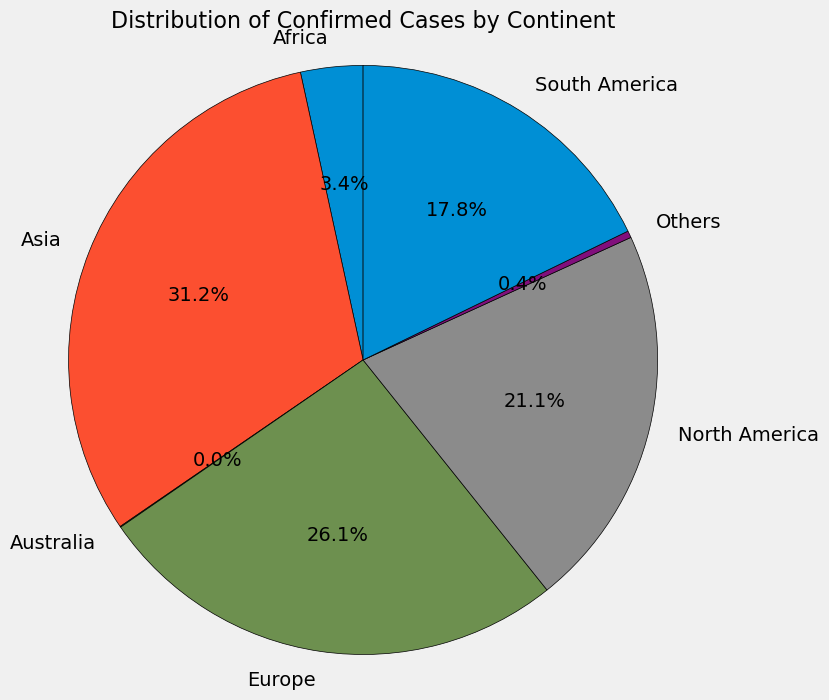

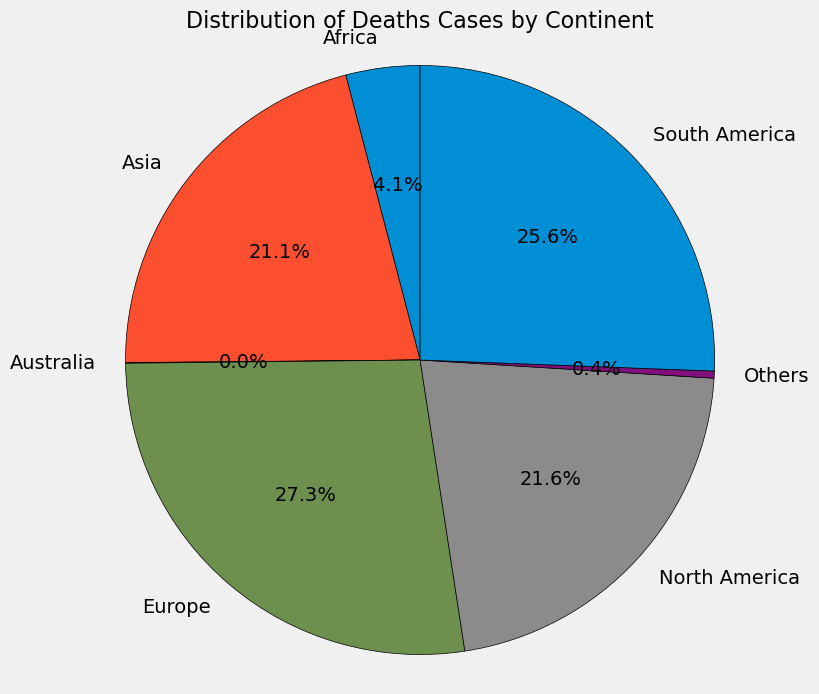

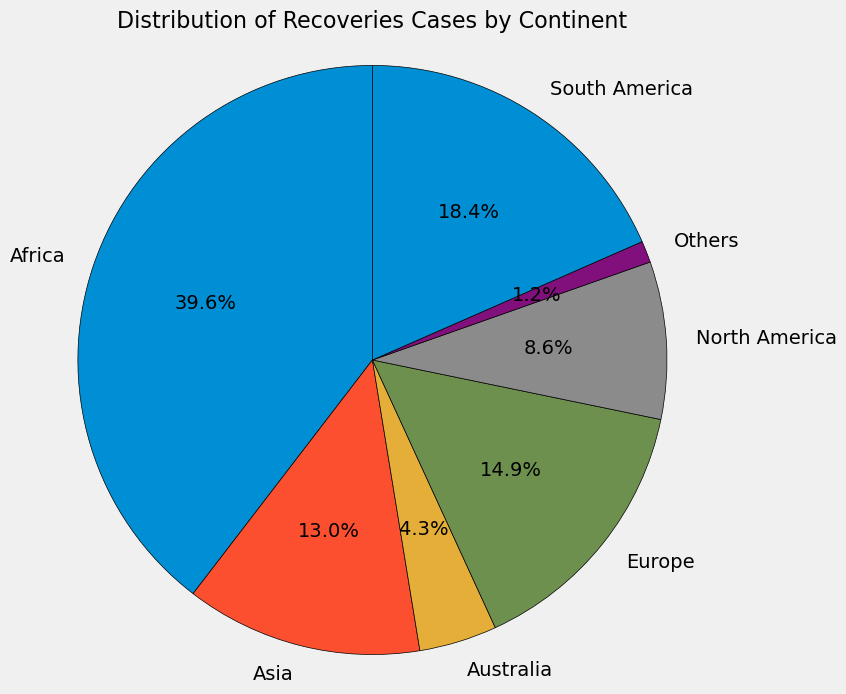

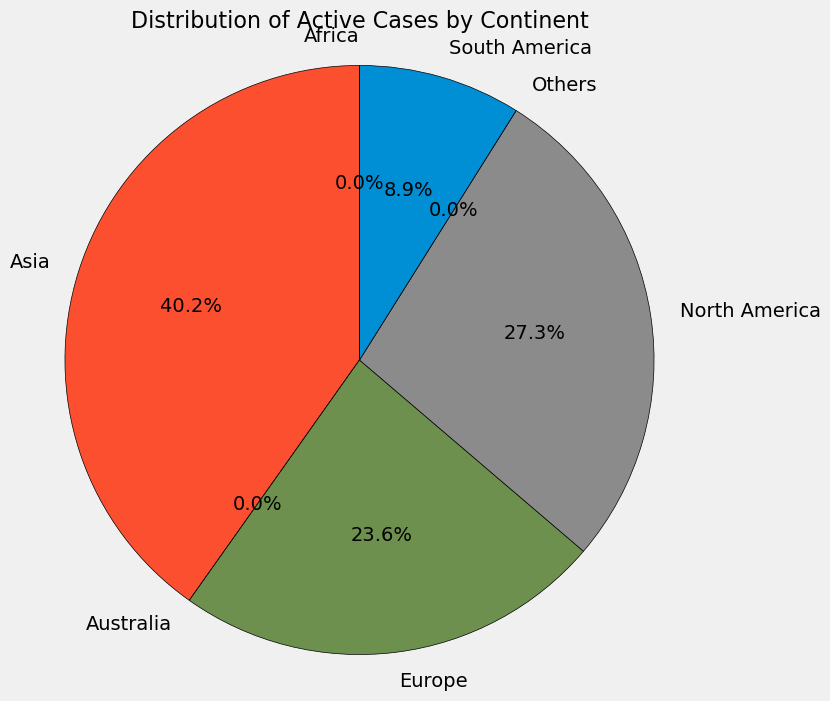

In [62]:
#Your code:
case_types = ['Confirmed', 'Deaths', 'Recoveries', 'Active']

for case_type in case_types:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # All values are non-negative for the pie chart
    values = Continental_df[case_type].copy()
    values[values < 0] = 0  # Replace negative values with 0
    
    # Generate pie chart
    ax.pie(
        values,
        labels=Continental_df.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black'}
    )
    
    # Set title
    ax.set_title(f'Distribution of {case_type} Cases by Continent', fontsize=16)
    
    # Ensure circular plot
    ax.axis('equal')
    
    plt.show()